# Amazon Laptops — Matplotlib Visualization

This notebook uses the cleaned Amazon laptop dataset and Matplotlib for basic visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('amazon_laptops_cleaned.csv')
print(df.head())


     price  rating   brand   ram  storage   color   processor
0  69990.0     3.4      HP  16.0    512.0  Silver  Snapdragon
1  68699.0     3.0      HP  16.0    512.0  Silver       Intel
2  44999.0     4.0  Lenovo   8.0    512.0  Silver         AMD
3  42990.0     3.4    Acer   8.0    256.0  Silver         AMD
4  73990.0     4.8   Apple   8.0    256.0  Silver       Apple


In [2]:
# Check dataset information
print(df.shape)
print(df.info())


(470, 7)
<class 'pandas.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      470 non-null    float64
 1   rating     470 non-null    float64
 2   brand      470 non-null    str    
 3   ram        470 non-null    float64
 4   storage    470 non-null    float64
 5   color      470 non-null    str    
 6   processor  442 non-null    str    
dtypes: float64(4), str(3)
memory usage: 25.8 KB
None


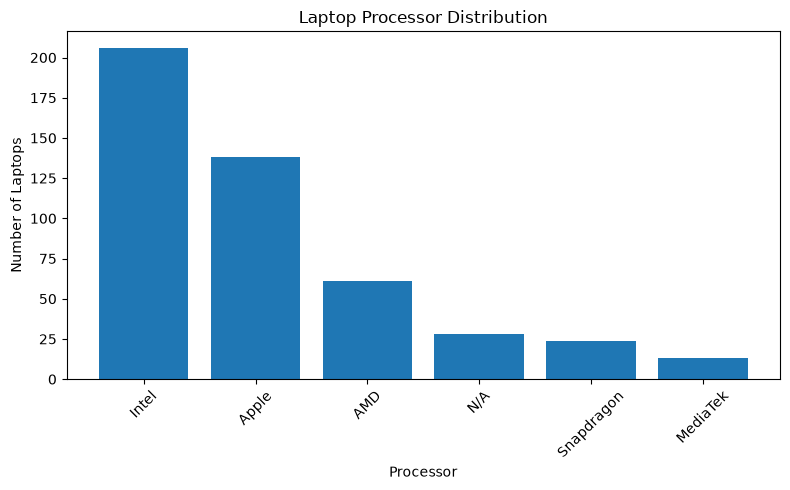

In [3]:
# 1. Processor Distribution
processor_counts = df['processor'].fillna('N/A').value_counts()

plt.figure(figsize=(8, 5))
plt.bar(processor_counts.index, processor_counts.values)
plt.xlabel('Processor')
plt.ylabel('Number of Laptops')
plt.title('Laptop Processor Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


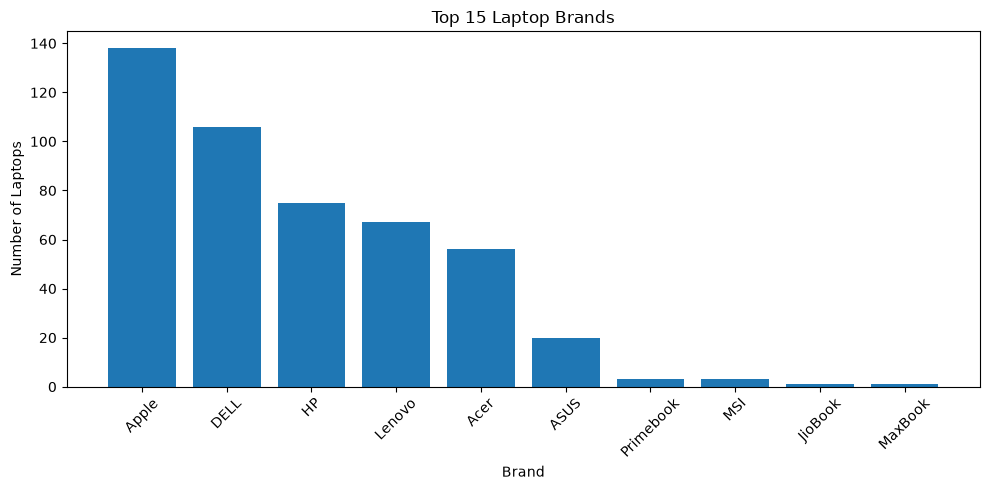

In [4]:
# 2. Brand Distribution
brand_counts = df['brand'].fillna('N/A').value_counts().head(15)

plt.figure(figsize=(10, 5))
plt.bar(brand_counts.index, brand_counts.values)
plt.xlabel('Brand')
plt.ylabel('Number of Laptops')
plt.title('Top 15 Laptop Brands')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


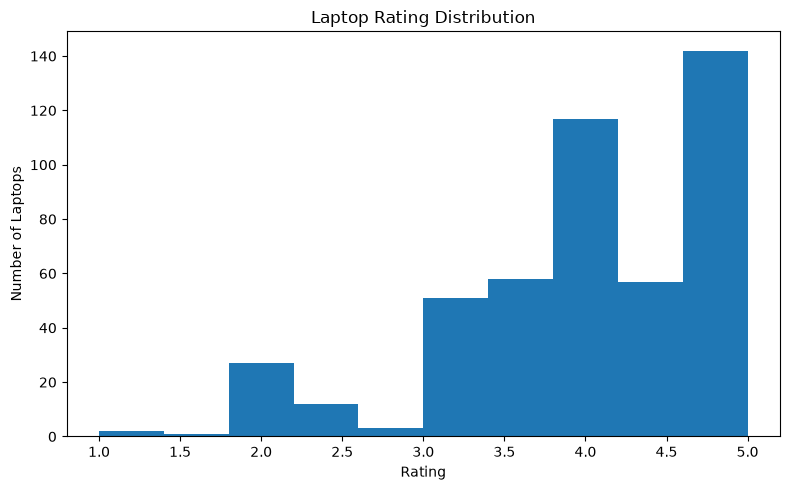

In [5]:
# 3. Rating Distribution
rating = pd.to_numeric(df['rating'], errors='coerce').dropna()

plt.figure(figsize=(8, 5))
plt.hist(rating, bins=10)
plt.xlabel('Rating')
plt.ylabel('Number of Laptops')
plt.title('Laptop Rating Distribution')
plt.tight_layout()
plt.show()


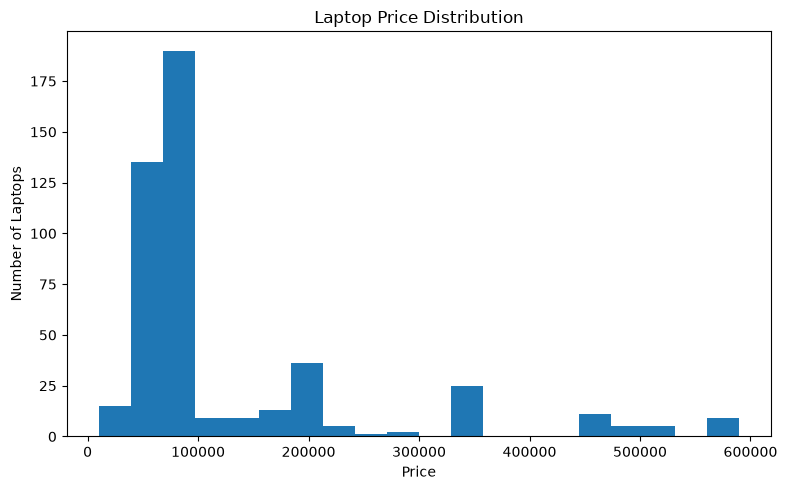

In [6]:
# 4. Price Distribution
price = (
    df['price'].astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
)
price = pd.to_numeric(price, errors='coerce').dropna()

plt.figure(figsize=(8, 5))
plt.hist(price, bins=20)
plt.xlabel('Price')
plt.ylabel('Number of Laptops')
plt.title('Laptop Price Distribution')
plt.tight_layout()
plt.show()


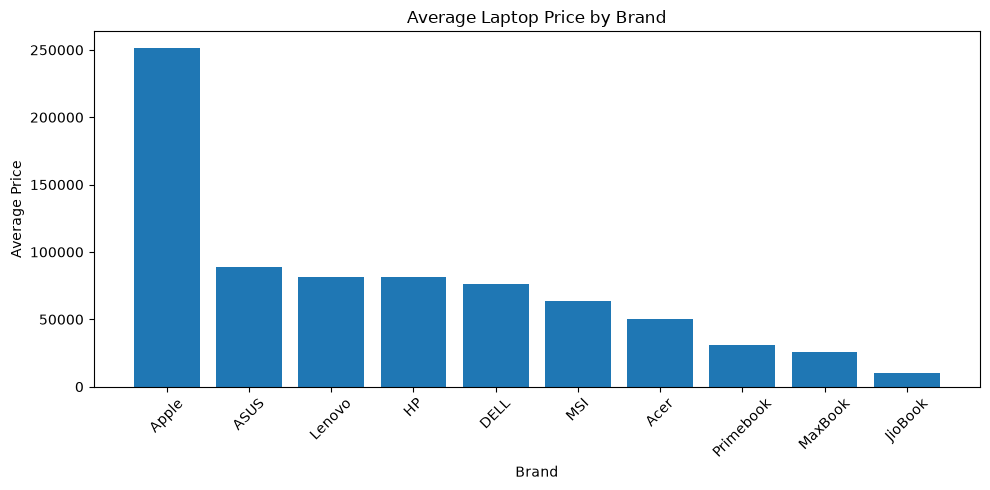

In [7]:
# 5. Average Price by Brand
temp = df.copy()
temp['price_numeric'] = pd.to_numeric(
    temp['price'].astype(str).str.replace(',', '', regex=False)
    .str.extract(r'(\d+(?:\.\d+)?)')[0],
    errors='coerce'
)

avg_price = temp.groupby('brand')['price_numeric'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(avg_price.index, avg_price.values)
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.title('Average Laptop Price by Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


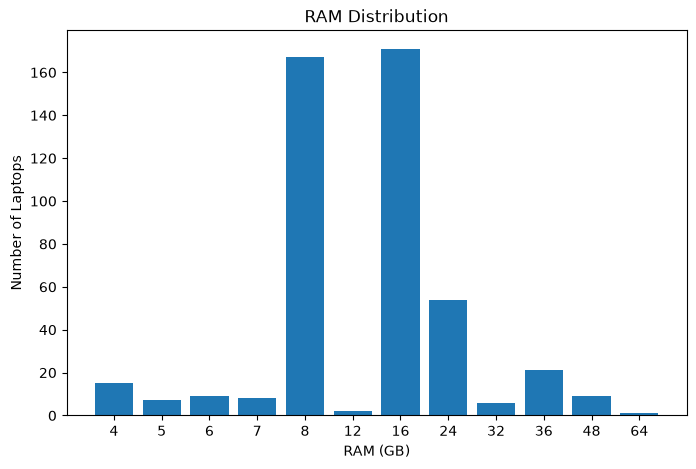

In [8]:
# 6. RAM Distribution
ram = df['ram'].astype(str).str.extract(r'(\d+)')[0]
ram = pd.to_numeric(ram, errors='coerce').dropna()
ram_counts = ram.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ram_counts.index.astype(str), ram_counts.values)
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Laptops')
plt.title('RAM Distribution')
plt.show()


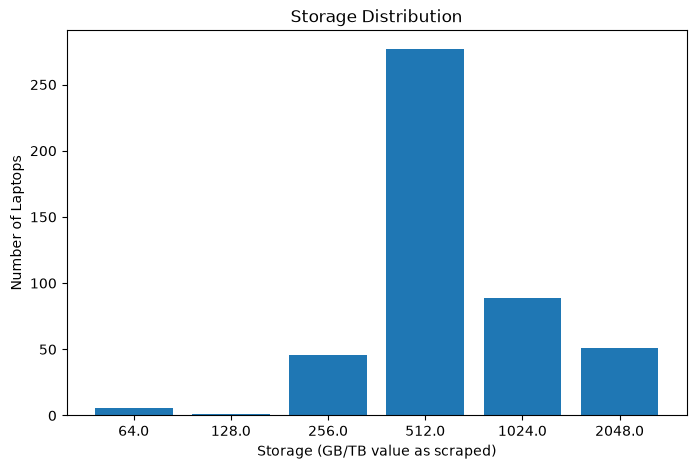

In [9]:
# 7. Storage Distribution
storage = df['storage'].astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0]
storage = pd.to_numeric(storage, errors='coerce').dropna()
storage_counts = storage.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(storage_counts.index.astype(str), storage_counts.values)
plt.xlabel('Storage (GB/TB value as scraped)')
plt.ylabel('Number of Laptops')
plt.title('Storage Distribution')
plt.show()


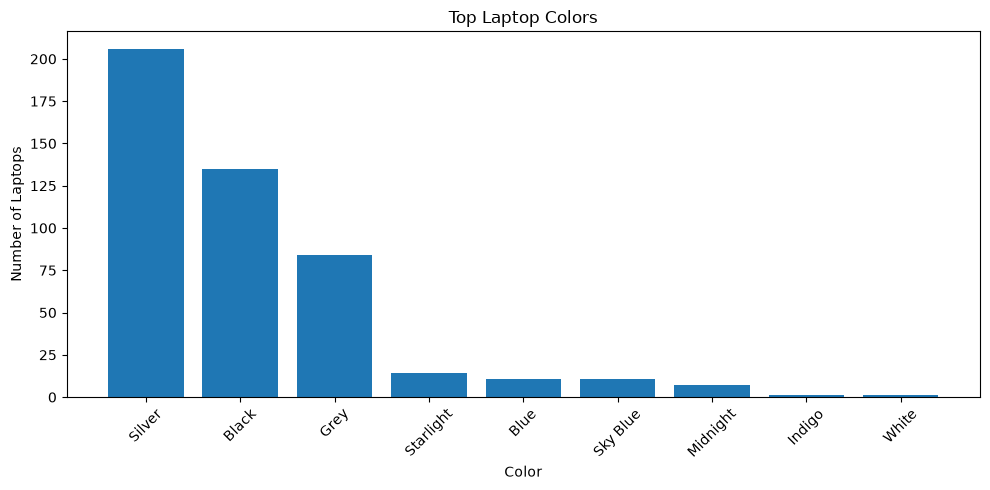

In [10]:
# 8. Color Distribution
color_counts = df['color'].fillna('N/A').value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(color_counts.index, color_counts.values)
plt.xlabel('Color')
plt.ylabel('Number of Laptops')
plt.title('Top Laptop Colors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


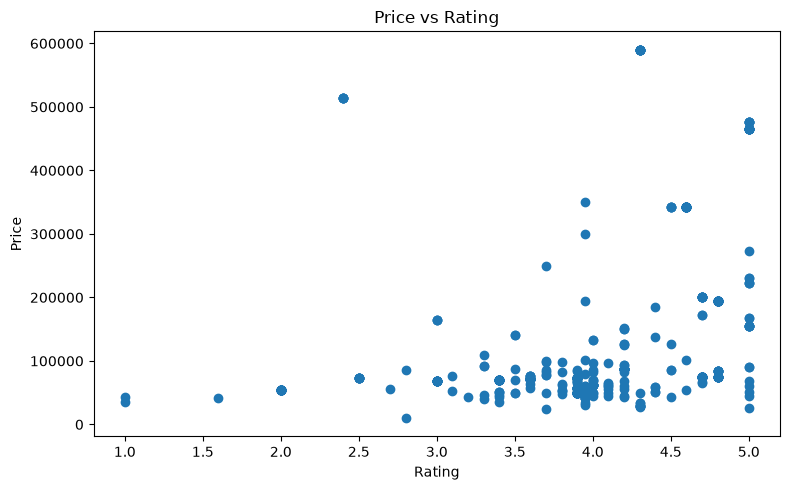

In [11]:
# 9. Price vs Rating
plot_df = temp[['price_numeric']].copy()
plot_df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce')
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df['rating_numeric'], plot_df['price_numeric'])
plt.xlabel('Rating')
plt.ylabel('Price')
plt.title('Price vs Rating')
plt.tight_layout()
plt.show()


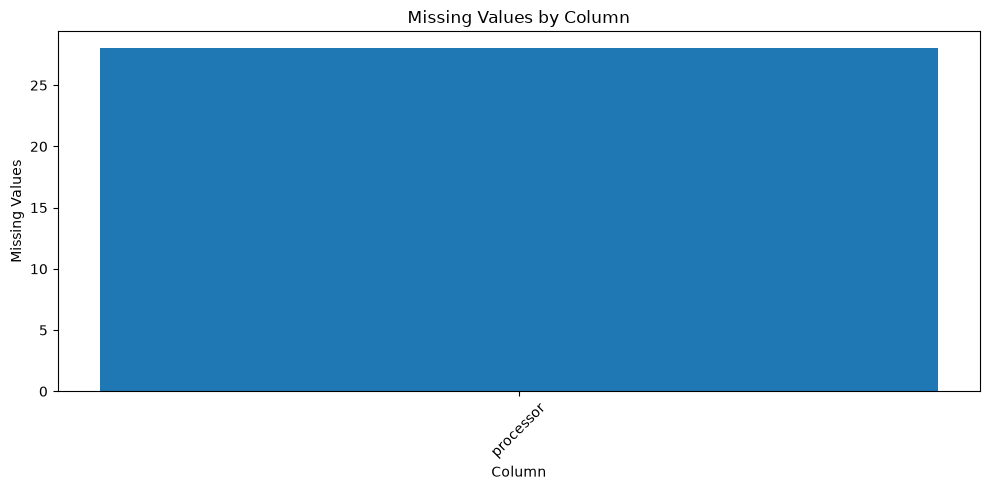

In [12]:
# 10. Missing Values Overview
missing = df.isna().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
plt.bar(missing.index, missing.values)
plt.xlabel('Column')
plt.ylabel('Missing Values')
plt.title('Missing Values by Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
